### Projet 5A : Modélisation Avancée (Random Forest & SHAP)

**Objectif :** Dépasser les limites de la régression logistique en utilisant un modèle non-linéaire (Random Forest) capable de capturer des interactions complexes entre les variables.

**Pourquoi Random Forest ?**
* Gère naturellement les relations non-linéaires (ex: effet de seuil sur les cotes).
* Robuste aux outliers et au bruit.
* Moins sensible à la multicollinéarité que la régression logistique.

**Pourquoi SHAP ?**
* Pour expliquer les prédictions : Quelles variables pèsent le plus ?
* Pour comprendre le sens : Est-ce qu'une différence de forme positive favorise toujours la victoire ?

### Imports et Configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.model_selection import TimeSeriesSplit

# Configuration
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
shap.initjs() # Nécessaire pour les graphiques SHAP interactifs

# Constantes
TARGET_COL = "FTResult"
TARGET_MAPPER = {'H': 0, 'D': 1, 'A': 2}
CLASS_LABELS = ["Home", "Draw", "Away"]

### Préparation des Données
Contrairement à la régression logistique :
1.  **Pas besoin de standardiser** (StandardScaler) : Les arbres sont insensibles à l'échelle.
2.  **Moins de contraintes de collinéarité :** On peut garder les cotes brutes ET les probabilités si on veut, le modèle choisira la meilleure coupure.

In [22]:
import pandas as pd
import numpy as np
import config as cfg
import importlib
importlib.reload(cfg)

# --- Constantes ---
TARGET_COL = "FTResult"  # Colonne cible : H, D, A
TARGET_MAPPER = {"H": 0, "D": 1, "A": 2}
CLASS_LABELS = ["Home Win", "Draw", "Away Win"]

def load_data_for_trees(path):
    """
    Charge et prépare les données pour les modèles d'arbres.
    """
    path_str = str(path)
    
    try:
        df = pd.read_csv(path_str, sep=";", parse_dates=["MatchDate"], dayfirst=True)
    except:
        df = pd.read_csv(path_str, sep=",", parse_dates=["MatchDate"], dayfirst=True)
    
    # 1. Encodage Cible
    if TARGET_COL in df.columns:
        df = df[df[TARGET_COL].isin(["H", "D", "A"])].copy()
        df["target"] = df[TARGET_COL].map(TARGET_MAPPER)
    
    # 2. Sélection des Features disponibles et pertinentes
    candidate_features = [
        "EloDiff",              # Différence de force (Elo)
        "Form5Diff",            # Dynamique récente
        "Form3Diff",            # Dynamique court terme
        "EloAdvantage",         # Avantage Elo normalisé           # Écart attendu
        "Season",               # Contexte temporel
        "HomeEloChange3M",      # Momentum Elo
        "AwayEloChange3M"
    ]
    
    # Filtrage : on ne garde que les colonnes existantes
    features = [c for c in candidate_features if c in df.columns]
    
    # 3. Nettoyage NaN/Inf
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # Vérifier que target existe
    cols_to_check = features + (["target"] if "target" in df.columns else [])
    df = df.dropna(subset=cols_to_check).reset_index(drop=True)
    
    # Tri temporel
    if "MatchDate" in df.columns:
        df = df.sort_values("MatchDate").reset_index(drop=True)
    
    print(f"✓ Données chargées : {df.shape[0]} matchs, {len(features)} features")
    return df, features

# --- Exécution ---
print(f"📂 Chargement du fichier : {cfg.FILE_SELECT}")
df_tree, tree_features = load_data_for_trees(cfg.FILE_SELECT)

print(f"\n📊 Résumé des données:")
print(f"  - Shape : {df_tree.shape}")
print(f"  - Features : {tree_features}")
print(f"  - Distribution cible : \n{df_tree['target'].value_counts().sort_index()}")
print(f"\n📋 Aperçu des données :")
print(df_tree[tree_features + ["target", "FTResult"]].head(10))


📂 Chargement du fichier : C:\Users\simon\Documents\git\Projet_5A\Donnees\matches_select_championnats.csv
✓ Données chargées : 46087 matchs, 7 features

📊 Résumé des données:
  - Shape : (46087, 49)
  - Features : ['EloDiff', 'Form5Diff', 'Form3Diff', 'EloAdvantage', 'Season', 'HomeEloChange3M', 'AwayEloChange3M']
  - Distribution cible : 
target
0    20561
1    11931
2    13595
Name: count, dtype: int64

📋 Aperçu des données :
   EloDiff  Form5Diff  Form3Diff  EloAdvantage  Season  HomeEloChange3M  \
0  -168.86       -2.0       -3.0     -0.053956    2006            -2.29   
1   -37.34        6.0        3.0     -0.013381    2006            23.12   
2   -39.16        1.0        3.0     -0.013458    2006           -30.10   
3   125.73        3.0        0.0      0.039103    2006            -1.01   
4   -53.35       -1.0        0.0     -0.018215    2006            -9.47   
5    -1.43        1.0        2.0     -0.000521    2006            -5.53   
6   -30.51        1.0        3.0     -0.0104

### Entraînement du Random Forest
On utilise toujours une validation temporelle (`TimeSeriesSplit`) pour ne pas tricher avec le futur.
Nous limitons la profondeur des arbres (`max_depth`) pour éviter le sur-apprentissage (overfitting), très courant sur les données sportives bruitées.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

def run_random_forest(df, features, n_splits=5):
    """
    Entraîne un Random Forest avec validation croisée temporelle.
    Retourne le meilleur modèle et les données de validation pour SHAP.
    """
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    X = df[features]
    y = df["target"]
    
    results = []
    last_model = None
    last_X_val = None
    last_y_val = None
    
    print(f"\n{'='*70}")
    print(f"🎯 VALIDATION CROISÉE TEMPORELLE ({n_splits} splits)")
    print(f"{'='*70}")
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Configuration optimisée du RF
        clf = RandomForestClassifier(
            n_estimators=500,           # Plus d'arbres = meilleure stabilité
            max_depth=10,               # Profondeur contrôlée
            min_samples_leaf=10,        # Évite surapprentissage
            min_samples_split=50,       # Split min
            max_features='sqrt',        # Diversité entre arbres
            random_state=42,
            n_jobs=-1,                  # Parallélisation
            class_weight='balanced'     # Adapte aux déséquilibres
        )
        
        clf.fit(X_train, y_train)
        
        # Prédictions
        y_pred = clf.predict(X_val)
        y_prob = clf.predict_proba(X_val)
        
        # Métriques complètes
        acc = accuracy_score(y_val, y_pred)
        ll = log_loss(y_val, y_prob)
        
        # Classification report par classe
        report = classification_report(y_val, y_pred, output_dict=True)
        
        results.append({
            'fold': fold + 1,
            'accuracy': acc,
            'log_loss': ll,
            'model': clf,
            'X_train_size': len(train_idx),
            'X_val_size': len(val_idx)
        })
        
        print(f"Fold {fold+1:d} | Accuracy: {acc:7.2%} | LogLoss: {ll:7.4f} | "
              f"Train: {len(train_idx):,} | Val: {len(val_idx):,}")
        
        # Garder le dernier fold
        if fold == n_splits - 1:
            last_model = clf
            last_X_val = X_val
            last_y_val = y_val
    
    # Résumé
    mean_acc = np.mean([r['accuracy'] for r in results])
    std_acc = np.std([r['accuracy'] for r in results])
    mean_ll = np.mean([r['log_loss'] for r in results])
    
    print(f"{'='*70}")
    print(f"📊 RÉSUMÉ FINAL:")
    print(f"  Accuracy moyenne: {mean_acc:.2%} (+/- {std_acc:.2%})")
    print(f"  LogLoss moyen: {mean_ll:.4f}")
    print(f"{'='*70}\n")
    
    return last_model, last_X_val, last_y_val, tree_features

# Exécution
rf_model, X_val_shap, y_val_shap, features_used = run_random_forest(df_tree, tree_features, n_splits=5)


🎯 VALIDATION CROISÉE TEMPORELLE (5 splits)
Fold 1 | Accuracy:  44.45% | LogLoss:  1.0390 | Train: 7,682 | Val: 7,681
Fold 2 | Accuracy:  45.68% | LogLoss:  1.0217 | Train: 15,363 | Val: 7,681
Fold 3 | Accuracy:  46.31% | LogLoss:  1.0277 | Train: 23,044 | Val: 7,681
Fold 4 | Accuracy:  46.53% | LogLoss:  1.0272 | Train: 30,725 | Val: 7,681
Fold 5 | Accuracy:  46.32% | LogLoss:  1.0234 | Train: 38,406 | Val: 7,681
📊 RÉSUMÉ FINAL:
  Accuracy moyenne: 45.86% (+/- 0.76%)
  LogLoss moyen: 1.0278



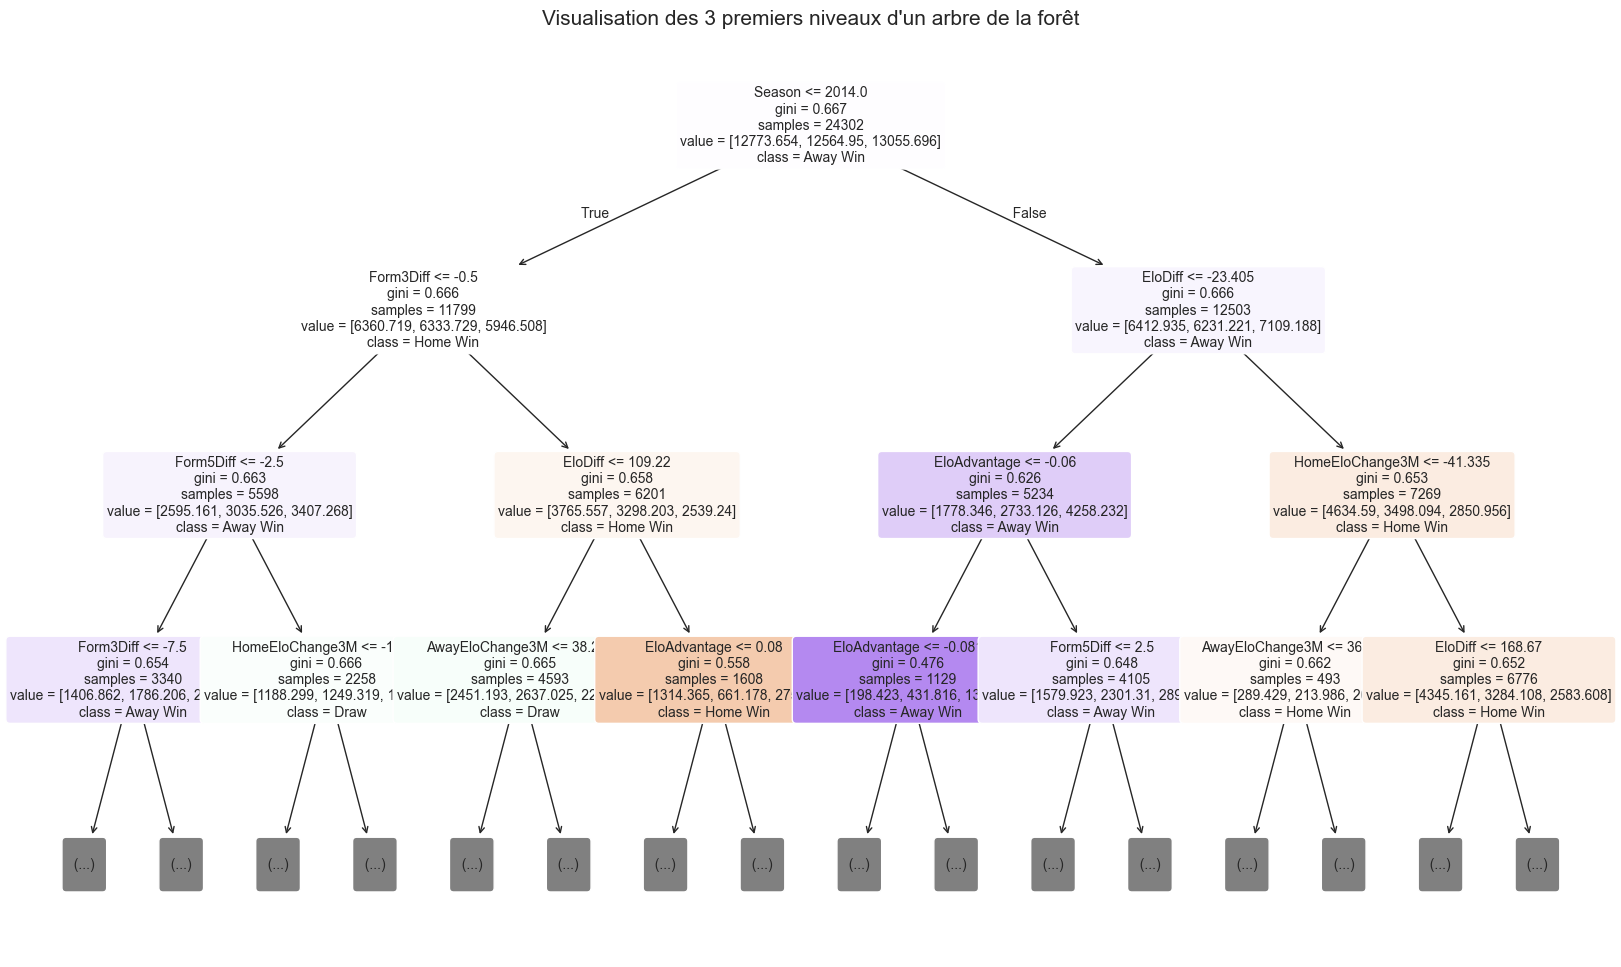

In [13]:
from sklearn.tree import plot_tree

# 1. Sélection d'un arbre spécifique (ex: le premier)
# rf_model.estimators_ est une liste contenant tes 300 arbres
one_tree = rf_model.estimators_[0]

# 2. Configuration de la figure
plt.figure(figsize=(20, 12))  # Grande taille pour lisibilité

# 3. Tracé de l'arbre
# On limite la profondeur affichée (max_depth=3) sinon c'est illisible
plot_tree(one_tree, 
          feature_names=features_used,    # Noms des variables
          class_names=CLASS_LABELS,       # ["Home", "Draw", "Away"]
          filled=True,                    # Coloriage selon la classe majoritaire
          rounded=True,                   # Coins arrondis (esthétique)
          fontsize=10,                    # Taille police
          max_depth=3);                   # On n'affiche que le haut de l'arbre

plt.title("Visualisation des 3 premiers niveaux d'un arbre de la forêt", fontsize=15)
plt.show()

⏳ Calcul des courbes d'apprentissage en cours... (Cela peut prendre quelques secondes)


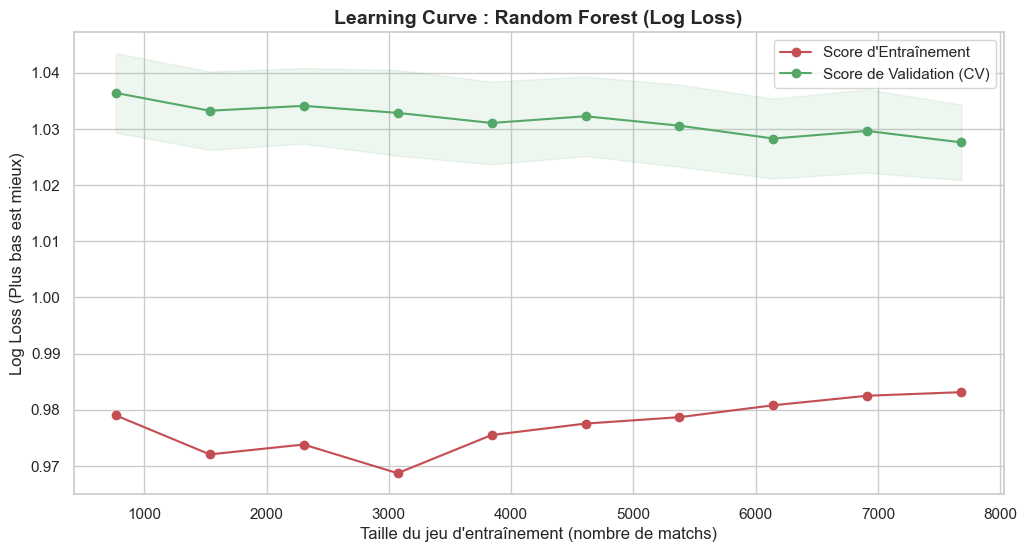

In [14]:
from sklearn.model_selection import learning_curve

def plot_learning_curve_time_series(estimator, X, y, title="Learning Curve"):
    """
    Génère les courbes d'apprentissage avec une validation croisée temporelle.
    """
    # On utilise TimeSeriesSplit pour respecter la chronologie
    cv = TimeSeriesSplit(n_splits=5)
    
    # Calcul des courbes (Note: on utilise neg_log_loss, donc on inversera le signe pour l'affichage)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, 
        cv=cv, 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), # 10 étapes de 10% à 100% du dataset
        scoring='neg_log_loss' 
    )
    
    # On repasse en positif pour le LogLoss (car sklearn renvoie du négatif pour maximiser)
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # --- Graphique ---
    plt.figure(figsize=(12, 6))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Taille du jeu d'entraînement (nombre de matchs)", fontsize=12)
    plt.ylabel("Log Loss (Plus bas est mieux)", fontsize=12)
    
    # Zone d'écart type (Variance)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Courbes moyennes
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score d'Entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de Validation (CV)")
    
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# --- Exécution ---
# On réutilise le modèle configuré précédemment (mais non entraîné, learning_curve gère le fit)
# Important : On utilise les mêmes features et hyperparamètres
model_for_curve = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,            # Ton paramètre actuel
    min_samples_leaf=30,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

print("⏳ Calcul des courbes d'apprentissage en cours... (Cela peut prendre quelques secondes)")
X_all = df_tree[tree_features]
y_all = df_tree["target"]

plot_learning_curve_time_series(model_for_curve, X_all, y_all, 
                                title="Learning Curve : Random Forest (Log Loss)")

### Analyse SHAP (SHapley Additive exPlanations)
SHAP permet de comprendre comment chaque feature a poussé la prédiction vers une équipe ou une autre.
* **Global Feature Importance :** Quelles variables comptent le plus ?
* **Beeswarm Plot :** Comment la valeur d'une variable influence le résultat (ex: EloDiff élevé => Victoire Home ?).

🔍 Calcul des valeurs SHAP...
✓ Valeurs SHAP calculées



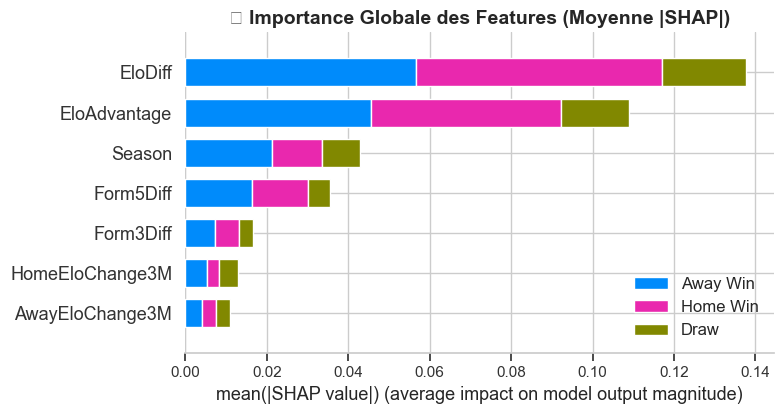

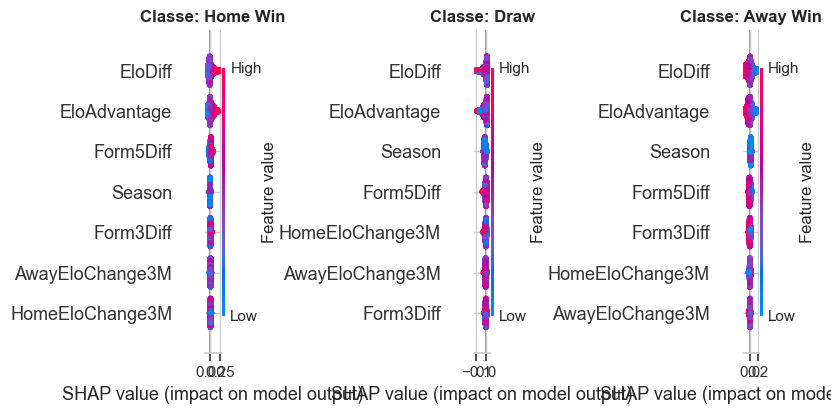

✓ Graphiques SHAP générés


In [15]:
# === SHAP ANALYSIS ===
print("🔍 Calcul des valeurs SHAP...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_val_shap, check_additivity=False)

# Gestion des formats possibles de SHAP
if isinstance(shap_values, list):
    shap_val_home = shap_values[0]
    shap_val_draw = shap_values[1]
    shap_val_away = shap_values[2]
else:
    shap_val_home = shap_values[:, :, 0]
    shap_val_draw = shap_values[:, :, 1]
    shap_val_away = shap_values[:, :, 2]

print("✓ Valeurs SHAP calculées\n")

# 1. IMPORTANCE GLOBALE DES FEATURES
fig, ax = plt.subplots(figsize=(12, 6))
plt.title("🎯 Importance Globale des Features (Moyenne |SHAP|)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_val_shap, plot_type="bar", 
                  class_names=CLASS_LABELS, show=False)
plt.tight_layout()
plt.show()

# 2. ANALYSE DÉTAILLÉE PAR CLASSE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (shap_vals, class_name) in enumerate([
    (shap_val_home, CLASS_LABELS[0]),
    (shap_val_draw, CLASS_LABELS[1]),
    (shap_val_away, CLASS_LABELS[2])
]):
    plt.sca(axes[idx])
    shap.summary_plot(shap_vals, X_val_shap, show=False, plot_type='dot')
    axes[idx].set_title(f"Classe: {class_name}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Graphiques SHAP générés")


### Matrice de Confusion
Vérifions si le Random Forest arrive mieux à prédire les matchs nuls que la Régression Logistique.

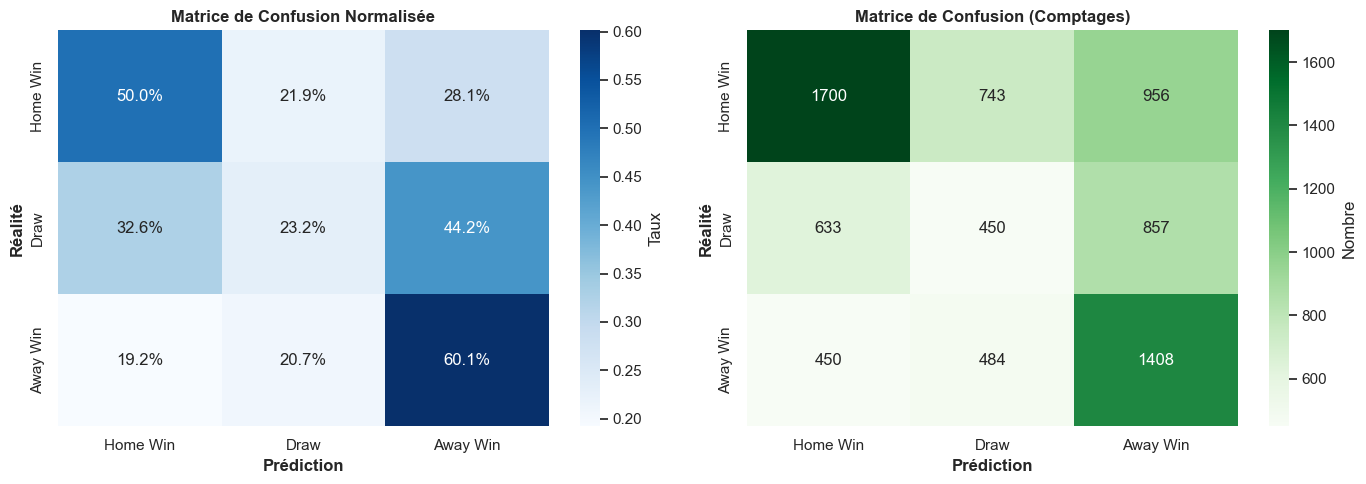


📈 RAPPORT DE CLASSIFICATION DÉTAILLÉ
              precision    recall  f1-score   support

    Home Win       0.61      0.50      0.55      3399
        Draw       0.27      0.23      0.25      1940
    Away Win       0.44      0.60      0.51      2342

    accuracy                           0.46      7681
   macro avg       0.44      0.44      0.44      7681
weighted avg       0.47      0.46      0.46      7681

📊 MÉTRIQUES GLOBALES:
  • Accuracy: 46.32%
  • LogLoss: 1.0234
  • Nombre de prédictions: 7,681


In [16]:
# === MATRICE DE CONFUSION ===
y_pred_final = rf_model.predict(X_val_shap)
y_prob_final = rf_model.predict_proba(X_val_shap)

cm = confusion_matrix(y_val_shap, y_pred_final, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matrice normalisée (pourcentages)
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=ax1, cbar_kws={'label': 'Taux'})
ax1.set_title("Matrice de Confusion Normalisée", fontsize=12, fontweight='bold')
ax1.set_ylabel("Réalité", fontweight='bold')
ax1.set_xlabel("Prédiction", fontweight='bold')

# Matrice brute (comptages)
cm_raw = confusion_matrix(y_val_shap, y_pred_final)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=ax2, cbar_kws={'label': 'Nombre'})
ax2.set_title("Matrice de Confusion (Comptages)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Réalité", fontweight='bold')
ax2.set_xlabel("Prédiction", fontweight='bold')

plt.tight_layout()
plt.show()

# === RAPPORT DE CLASSIFICATION ===
print("\n" + "="*70)
print("📈 RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*70)
print(classification_report(y_val_shap, y_pred_final, target_names=CLASS_LABELS))

# === MÉTRIQUES GLOBALES ===
acc_final = accuracy_score(y_val_shap, y_pred_final)
ll_final = log_loss(y_val_shap, y_prob_final)

print("="*70)
print(f"📊 MÉTRIQUES GLOBALES:")
print(f"  • Accuracy: {acc_final:.2%}")
print(f"  • LogLoss: {ll_final:.4f}")
print(f"  • Nombre de prédictions: {len(y_val_shap):,}")
print("="*70)


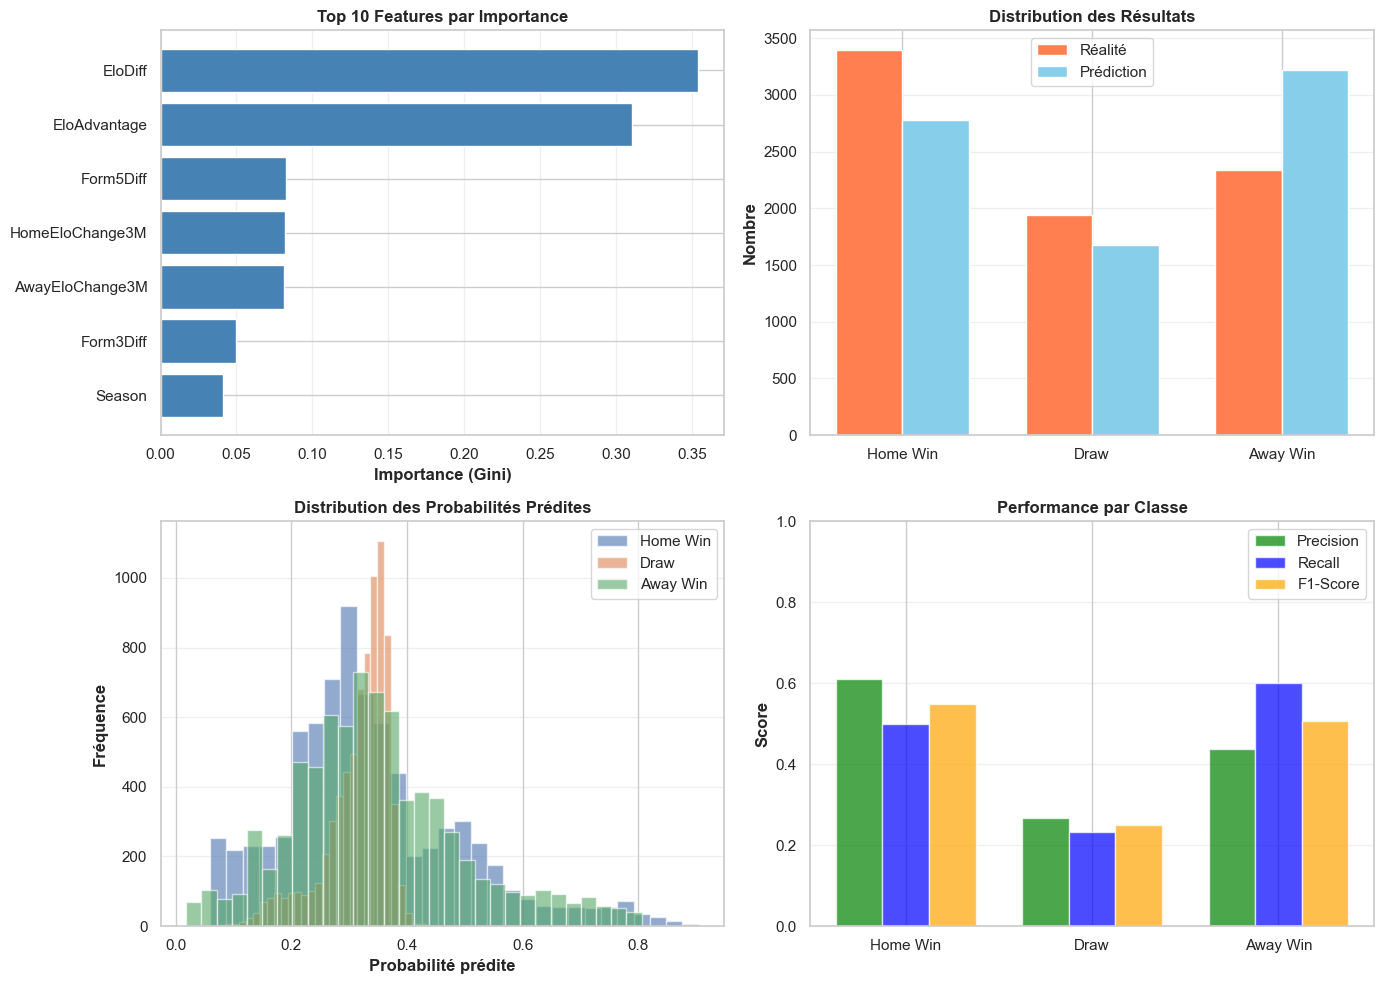

✓ Visualisations d'analyse générées


In [17]:
# === ANALYSE APPROFONDIE DES FEATURES ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importance (Impureté Gini)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10

ax = axes[0, 0]
ax.barh(range(len(indices)), importances[indices], color='steelblue')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features_used[i] for i in indices])
ax.set_xlabel('Importance (Gini)', fontweight='bold')
ax.set_title('Top 10 Features par Importance', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 2. Distribution des prédictions par classe
ax = axes[0, 1]
pred_counts = pd.Series(y_pred_final).value_counts().sort_index()
true_counts = pd.Series(y_val_shap).value_counts().sort_index()
x = np.arange(len(CLASS_LABELS))
width = 0.35
ax.bar(x - width/2, true_counts, width, label='Réalité', color='coral')
ax.bar(x + width/2, pred_counts, width, label='Prédiction', color='skyblue')
ax.set_ylabel('Nombre', fontweight='bold')
ax.set_title('Distribution des Résultats', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Probabilités prédites par classe
ax = axes[1, 0]
for i, label in enumerate(CLASS_LABELS):
    ax.hist(y_prob_final[:, i], bins=30, alpha=0.6, label=label)
ax.set_xlabel('Probabilité prédite', fontweight='bold')
ax.set_ylabel('Fréquence', fontweight='bold')
ax.set_title('Distribution des Probabilités Prédites', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Performance par classe avec classification_report
ax = axes[1, 1]
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_val_shap, y_pred_final, labels=[0, 1, 2], zero_division=0
)

x = np.arange(len(CLASS_LABELS))
width = 0.25
ax.bar(x - width, precision, width, label='Precision', color='green', alpha=0.7)
ax.bar(x, recall, width, label='Recall', color='blue', alpha=0.7)
ax.bar(x + width, f1, width, label='F1-Score', color='orange', alpha=0.7)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Performance par Classe', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisations d'analyse générées")


📉 Test Réaliste : Train (36869) -> Test (9218)
💰 RÉSULTATS BACKTEST (Pure Sport) :
  - Nombre de paris : 8786
  - ROI : -10.19%
  - Profit Total : -895.58 unités


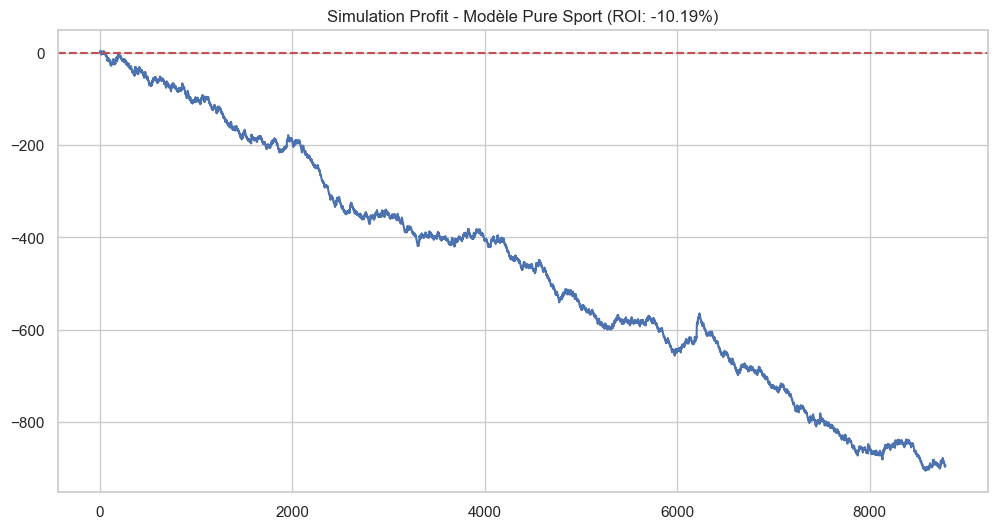

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. On redéfinit la fonction de Backtest (qui a besoin des cotes pour calculer l'argent)
def backtest_strategy(model, df, features, threshold=0.05):
    """
    Simule une stratégie de pari basée sur la Value.
    """
    # Prédictions du modèle (basées uniquement sur les features sportives)
    X = df[features]
    probs = model.predict_proba(X)
    
    # Construction du tableau de résultats
    results = df.copy()
    results['Prob_Home'] = probs[:, 0]
    results['Prob_Draw'] = probs[:, 1]
    results['Prob_Away'] = probs[:, 2]
    
    # Calcul de la Value (Ici on utilise les cotes du DF pour voir si on gagne de l'argent)
    results['Value_Home'] = (results['Prob_Home'] * results['OddHome']) - 1
    results['Value_Draw'] = (results['Prob_Draw'] * results['OddDraw']) - 1
    results['Value_Away'] = (results['Prob_Away'] * results['OddAway']) - 1
    
    bets = []
    
    for idx, row in results.iterrows():
        # On cherche la meilleure value
        max_val = max(row['Value_Home'], row['Value_Draw'], row['Value_Away'])
        
        if max_val > threshold:
            choice = None
            odds = 0
            bet_prob = 0
            
            if row['Value_Home'] == max_val:
                choice = 'H'; odds = row['OddHome']; bet_prob = row['Prob_Home']
            elif row['Value_Draw'] == max_val:
                choice = 'D'; odds = row['OddDraw']; bet_prob = row['Prob_Draw']
            else:
                choice = 'A'; odds = row['OddAway']; bet_prob = row['Prob_Away']
            
            # Vérification du résultat (0=H, 1=D, 2=A)
            target_map = {'H': 0, 'D': 1, 'A': 2}
            # Si target est déjà encodé en 0,1,2 ou en H,D,A, on adapte
            real_result = row['target'] if isinstance(row['target'], (int, float)) else target_map[row['FTResult']]
            choice_int = target_map[choice]
            
            is_win = (choice_int == real_result)
            profit = odds - 1 if is_win else -1
            
            bets.append({
                'Odds': odds,
                'Value': max_val,
                'Result': 'Win' if is_win else 'Loss',
                'Profit': profit
            })
            
    df_bets = pd.DataFrame(bets)
    
    if df_bets.empty:
        print("Aucun pari trouvé.")
        return

    # Affichage des résultats
    roi = df_bets['Profit'].sum() / len(df_bets)
    print(f"💰 RÉSULTATS BACKTEST (Pure Sport) :")
    print(f"  - Nombre de paris : {len(df_bets)}")
    print(f"  - ROI : {roi:.2%}")
    print(f"  - Profit Total : {df_bets['Profit'].sum():.2f} unités")
    
    # Graphique
    df_bets['Cumulative_Profit'] = df_bets['Profit'].cumsum()
    plt.figure(figsize=(12, 6))
    plt.plot(df_bets['Cumulative_Profit'], label='Profit Cumulé')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f"Simulation Profit - Modèle Pure Sport (ROI: {roi:.2%})")
    plt.show()

# 2. Définition des Features "Pure Sport" (SANS les cotes)
pure_sport_features = [
    "EloDiff", "EloAdvantage", 
    "Form5Diff", "Form3Diff", 
    "HomeEloChange3M", "AwayEloChange3M", 
    "Season"
]

# 3. Fonction de Test Réaliste (Train sur passé / Test sur futur)
def real_out_of_sample_test(df, features):
    # Split Temporel 80/20
    train_size = int(len(df) * 0.80)
    df_train = df.iloc[:train_size].copy()
    df_test = df.iloc[train_size:].copy()
    
    print(f"📉 Test Réaliste : Train ({len(df_train)}) -> Test ({len(df_test)})")

    # Entraînement sans voir les cotes
    model = RandomForestClassifier(
        n_estimators=500, min_samples_leaf=10, 
        max_features='sqrt', max_depth=10, 
        random_state=42, class_weight='balanced', n_jobs=-1
    )
    model.fit(df_train[features], df_train["target"])
    
    # Backtest sur le futur
    backtest_strategy(model, df_test, features, threshold=0.05)

# --- EXECUTION ---
# Assure-toi que df_tree contient toujours les colonnes OddHome/OddDraw/OddAway
# Le filtre se fait via la liste 'features'
real_out_of_sample_test(df_tree, pure_sport_features)